# EDA on Medical Dataset

In [48]:
# importing required libraries

import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline

import pickle

import warnings
warnings.filterwarnings('ignore')

In [49]:
# Loading dataset
df = pd.read_csv("Data\dataset1.csv")
print("Dataset Succesfully Loaded!")
df.head()

Dataset Succesfully Loaded!


,Body_Pain,Burning_Sensation,Itching,Excessive_Hunger,Frequent_Urination,Eye_Problems,Joint_Pain,Numbness,Weight_Gain,Weight_Loss,...,Constipation,Pulse_Rate_Decrease,Continuous_Sneezing,Cold.1,Blood_Clot,Pus_Filled_Pimple,Rashes,Mental_Anxiety,White_Spots_on_Mouth,Prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection


In [50]:
# Basic Overview

print("Shape of dataset:", df.shape)

print("\nData Types: \n", df.dtypes.value_counts())

print("\nMissing Values:", df.isnull().sum().sum())

print("\nColumns:")  
df.columns.tolist()[:] # for preview first 10 columns use this print("\nColumns:\n", df.columns.tolist()[:10])
print("\nFirst 5 rows of the dataset:")
print(df.head())

Shape of dataset: (757, 173)

Data Types: 
 int64     172
object      1
Name: count, dtype: int64

Missing Values: 0

Columns:

First 5 rows of the dataset:
   Body_Pain  Burning_Sensation  Itching  Excessive_Hunger  \
0          1                  1        1                 0   
1          1                  0        0                 0   
2          0                  1        0                 0   
3          0                  0        1                 0   
4          1                  1        0                 0   

   Frequent_Urination  Eye_Problems  Joint_Pain  Numbness  Weight_Gain  \
0                   0             0           0         0            0   
1                   0             0           0         0            0   
2                   0             0           0         0            0   
3                   0             0           0         0            0   
4                   0             0           0         0            0   

   Weight_Loss  ...  Cons

In [51]:
# Check for duplicate rows

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New shape: {df.shape}")


Number of duplicate rows: 32
Duplicate rows removed. New shape: (725, 173)


In [52]:
# Analyze the distribution of the target variable
print("\nValue counts for the 'Prognosis' column:")
prognosis_counts = df['Prognosis'].value_counts()
print(prognosis_counts)


Value counts for the 'Prognosis' column:
Prognosis
Dengue                     41
Diabetes                   25
Dysentery                  22
Conjunctivitis             18
Cancer                     16
                           ..
Cholera                     3
Acne                        3
Ringworm                    2
Otitis Media                2
Urinary Tract Infection     2
Name: count, Length: 85, dtype: int64


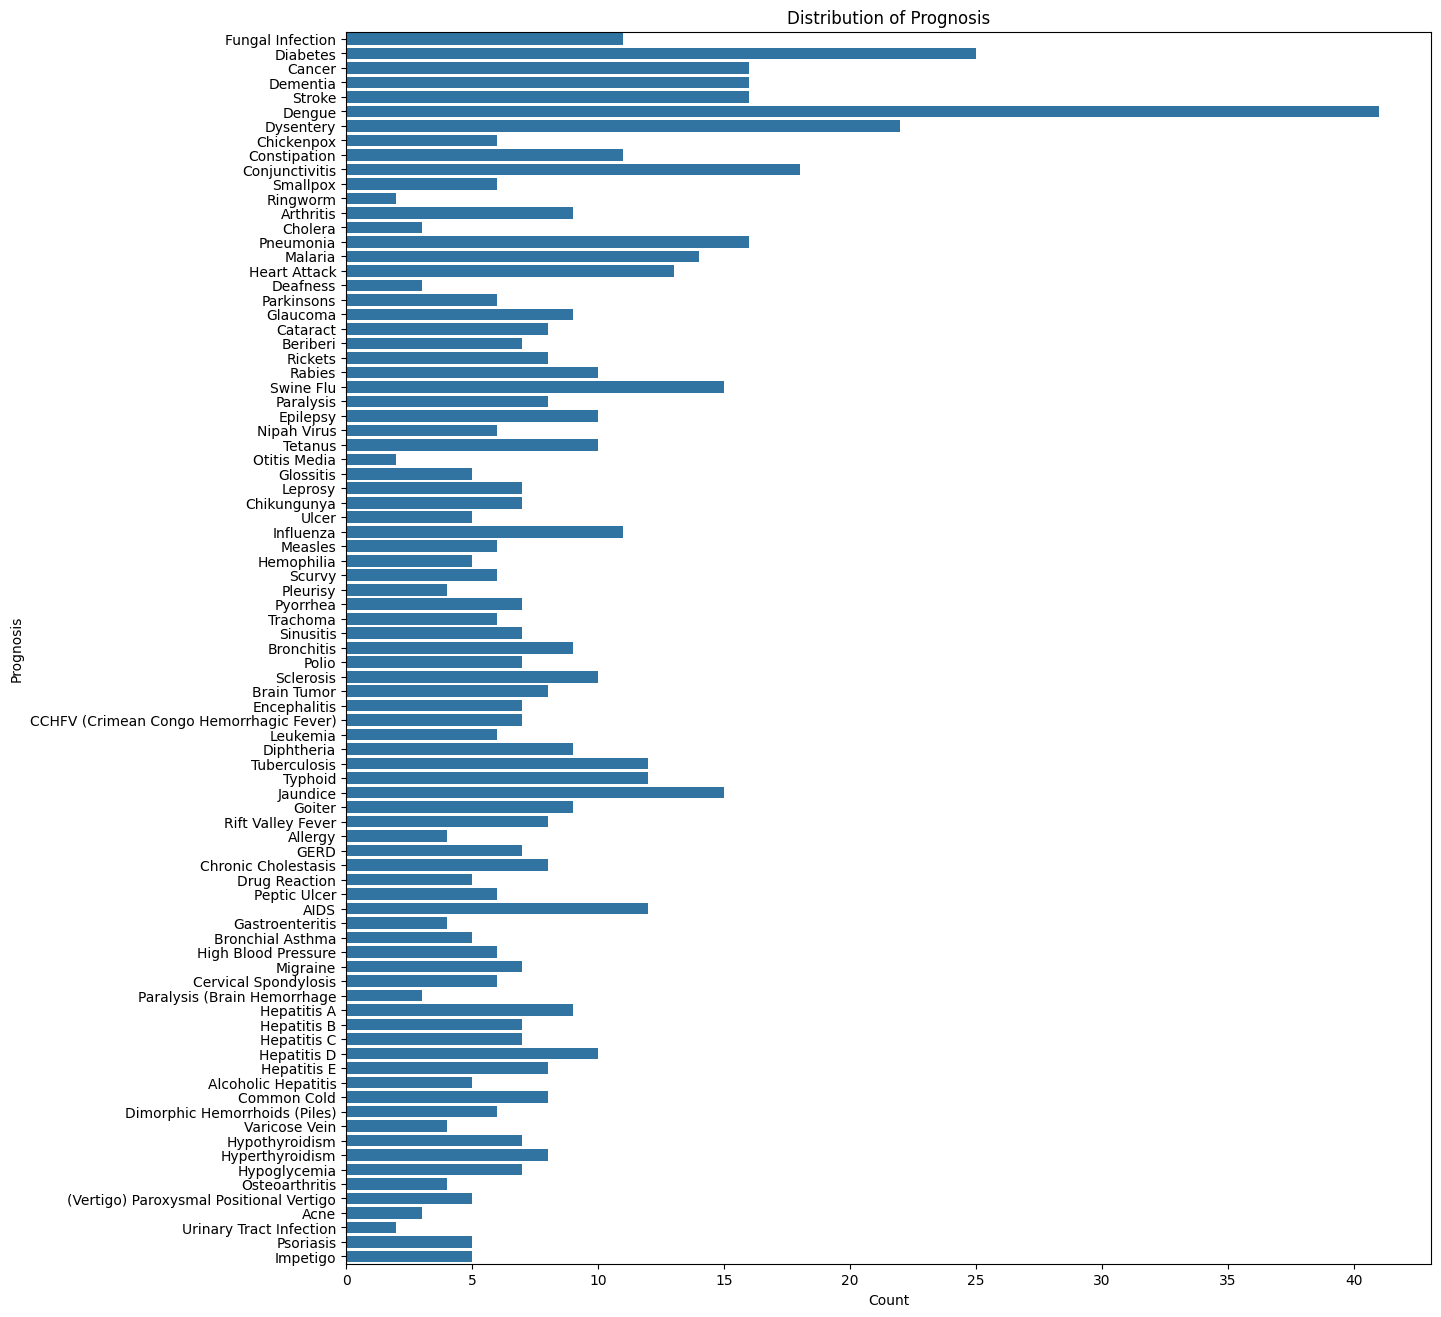

In [53]:
# Visualize the distribution of the target variable

plt.figure(figsize=(14, 16))
sns.countplot(y=df['Prognosis'])
plt.title('Distribution of Prognosis')
plt.xlabel('Count')
plt.ylabel('Prognosis')
plt.show()

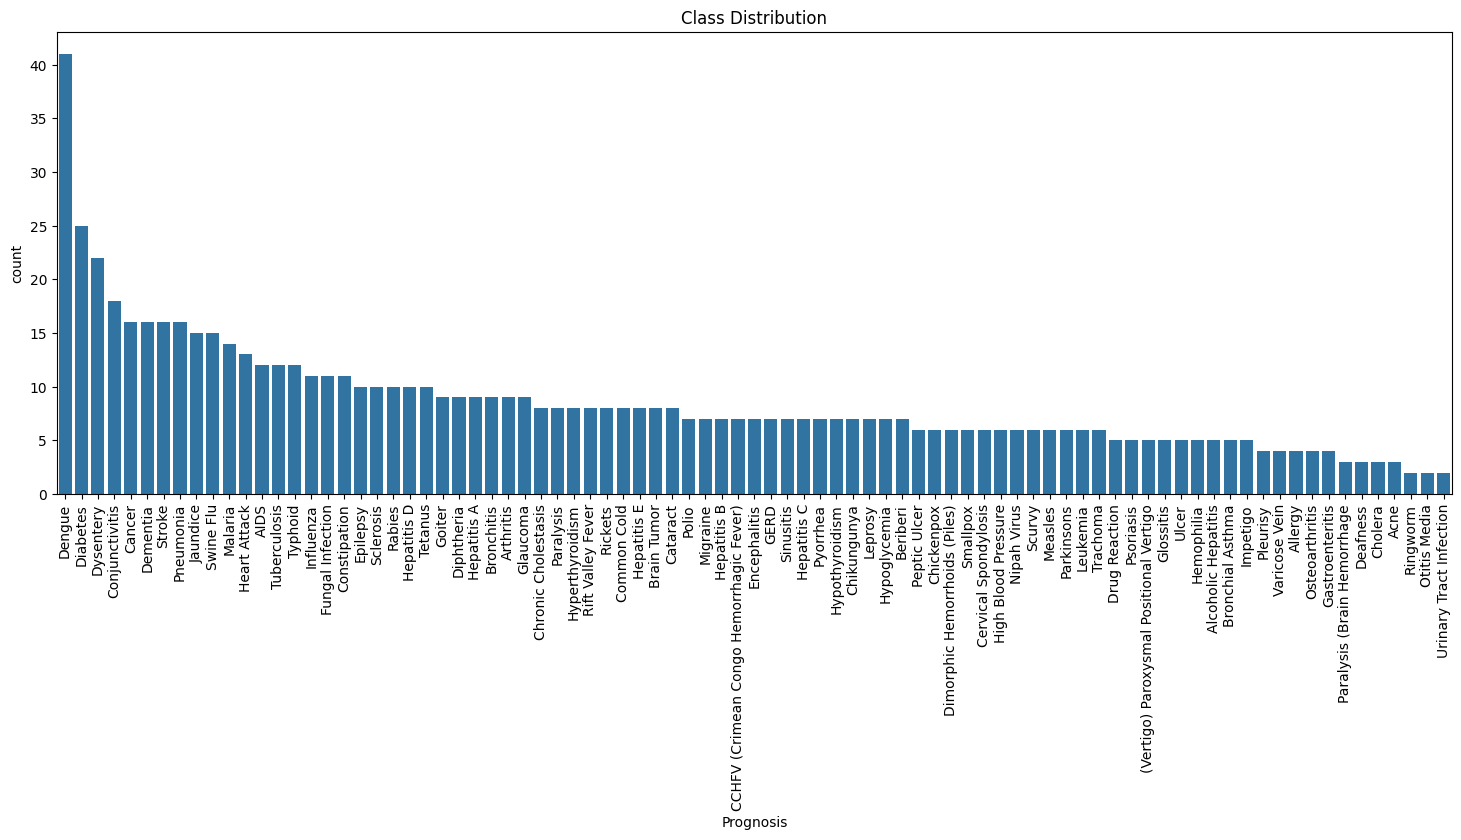

In [54]:
# Class Imbalance 

plt.figure(figsize=(18,6))
sns.countplot(data=df, x="Prognosis", order=df['Prognosis'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

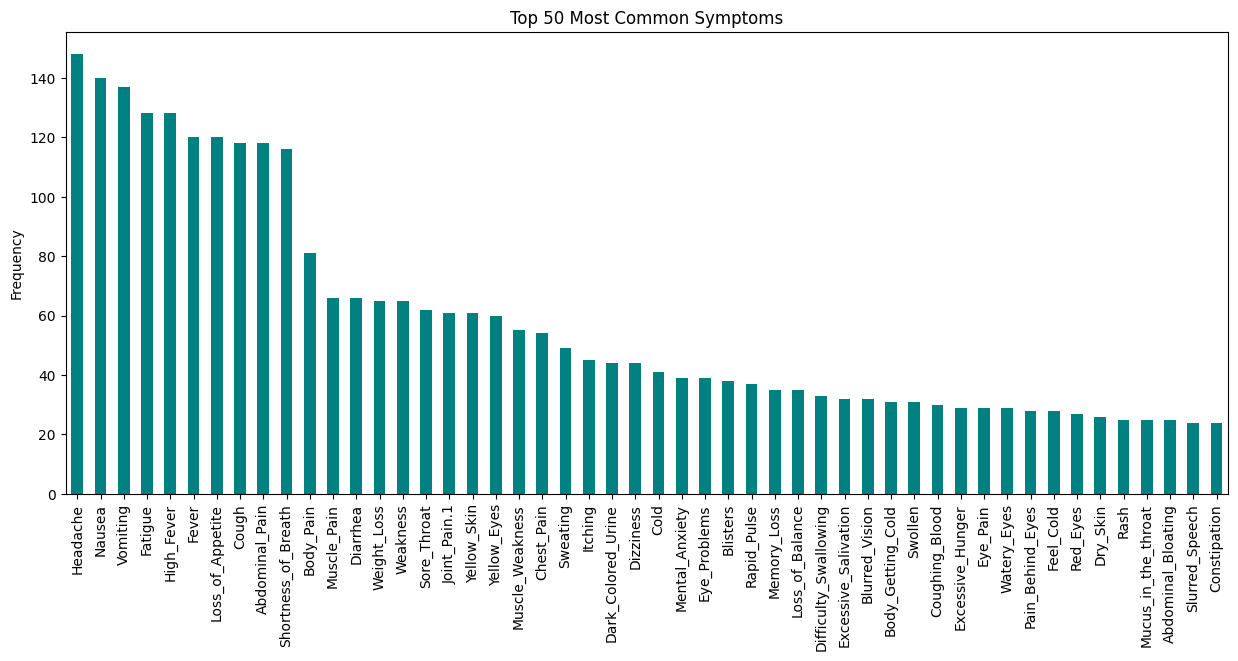

In [55]:
# Symptom Frequency

symptom_cols = df.drop("Prognosis", axis=1).columns

symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)



plt.figure(figsize=(15,6))
symptom_counts.head(50).plot(kind='bar', color="teal")
plt.title("Top 50 Most Common Symptoms")
plt.ylabel("Frequency")
plt.show()

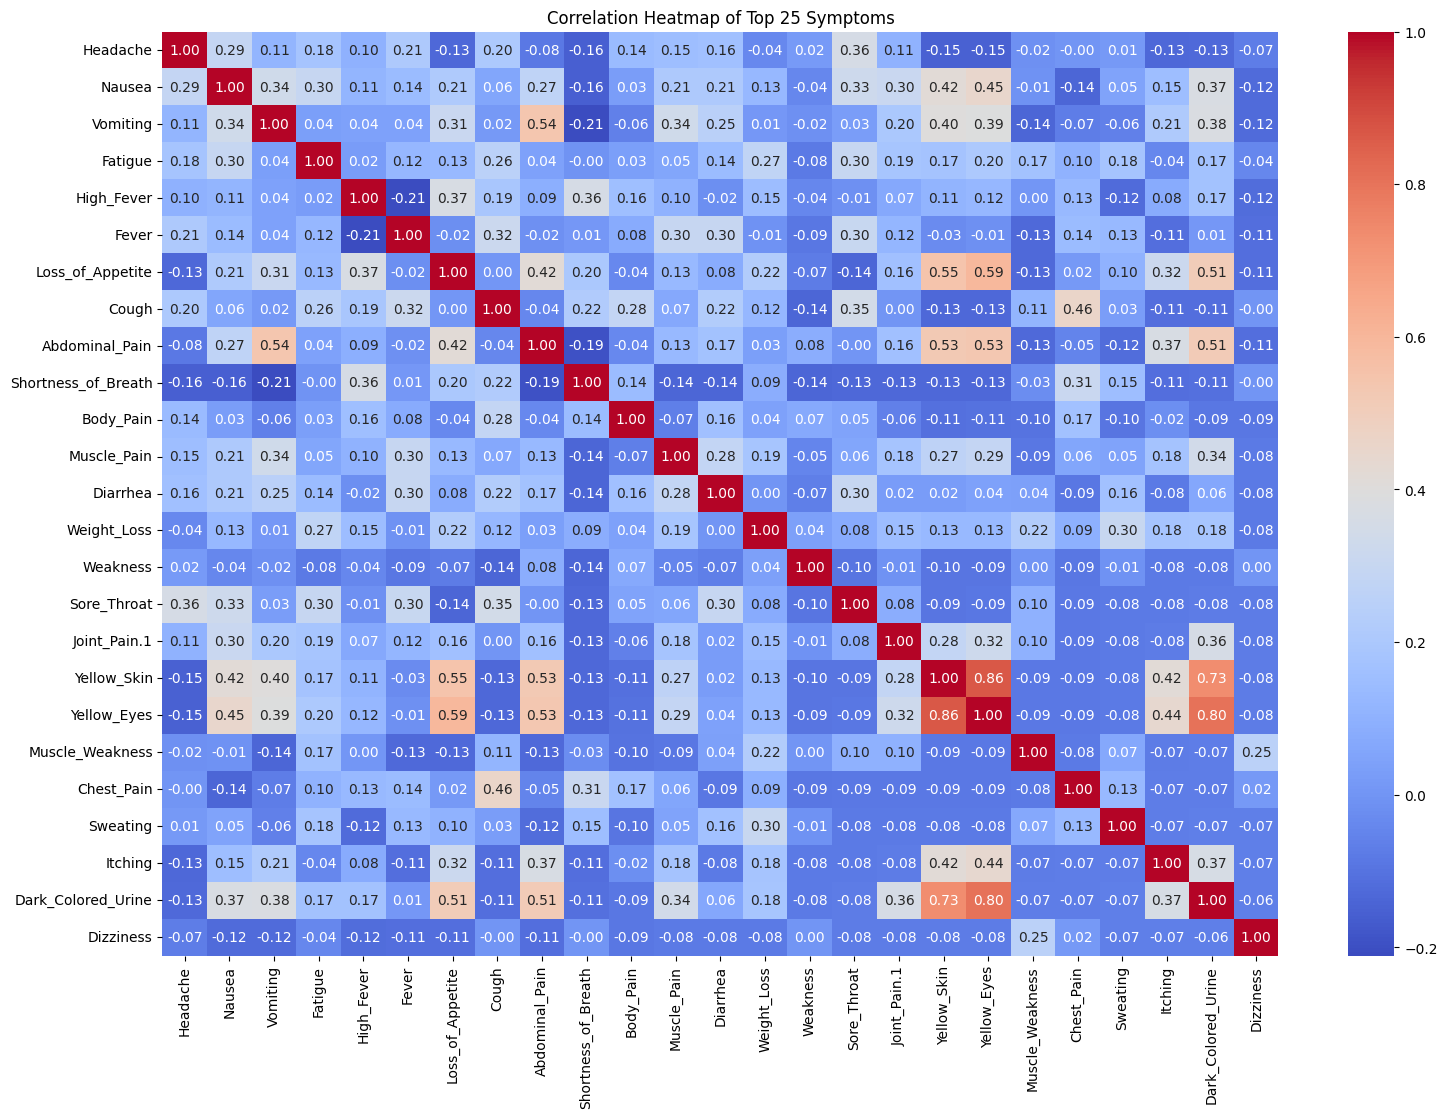

In [56]:
# Plot the Correlation Heatmap of Top 25 Symptoms 

# Find the top 25 most frequent symptoms
top_25_symptoms = df.drop('Prognosis', axis=1).sum().sort_values(ascending=False).head(25).index


# Create a correlation matrix for these symptoms
corr_matrix = df[top_25_symptoms].corr()
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top 25 Symptoms')
plt.show()

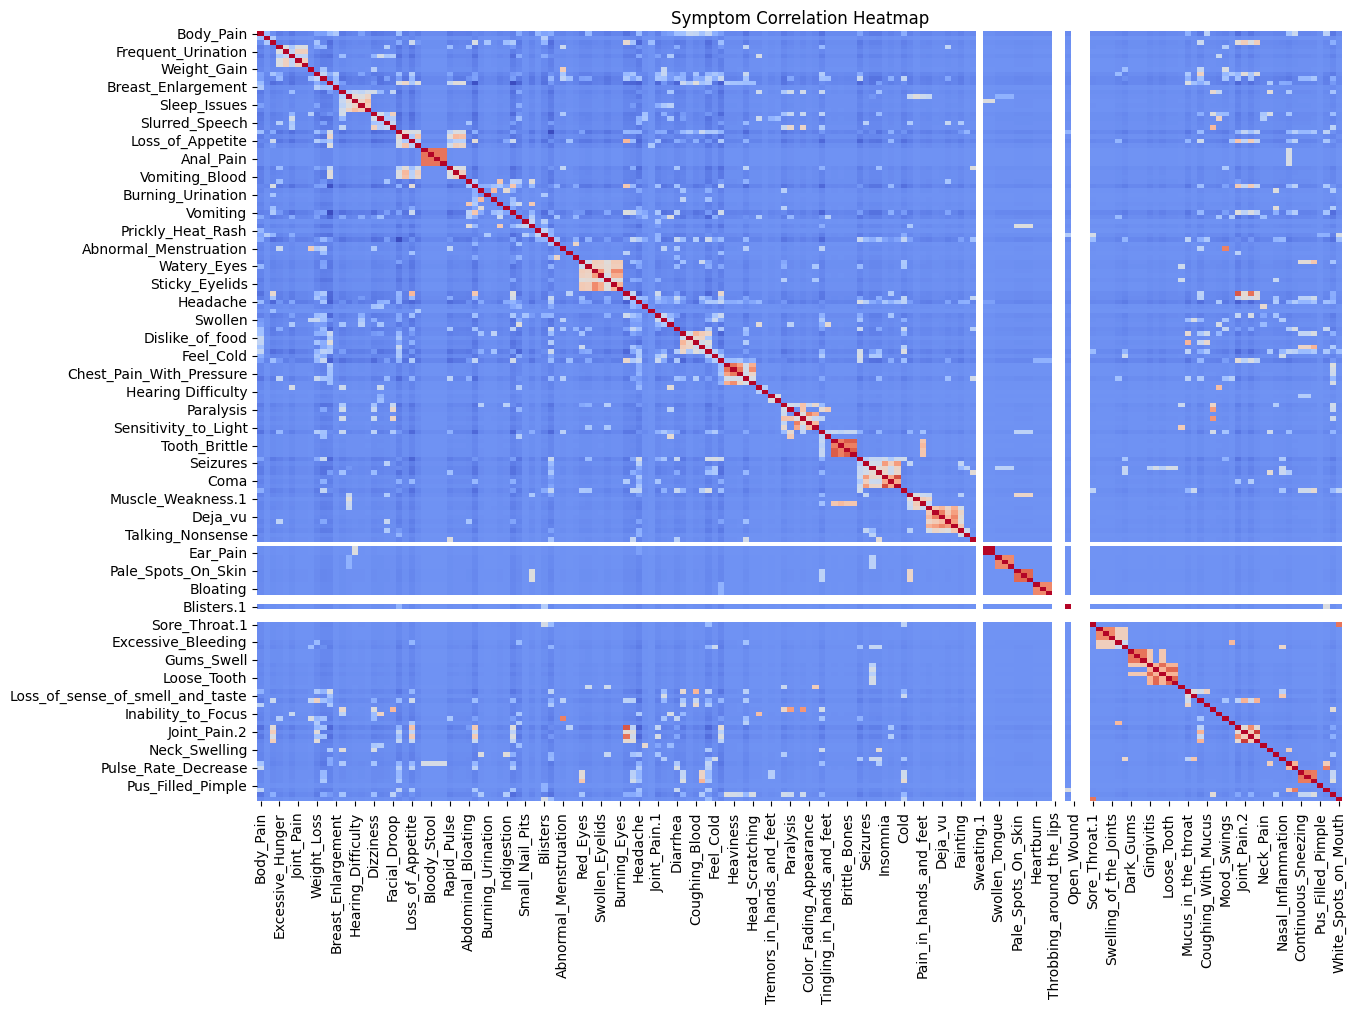

In [57]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
corr = df[symptom_cols].corr()
sns.heatmap(corr, cmap="coolwarm", cbar=False)
plt.title("Symptom Correlation Heatmap")
plt.show()

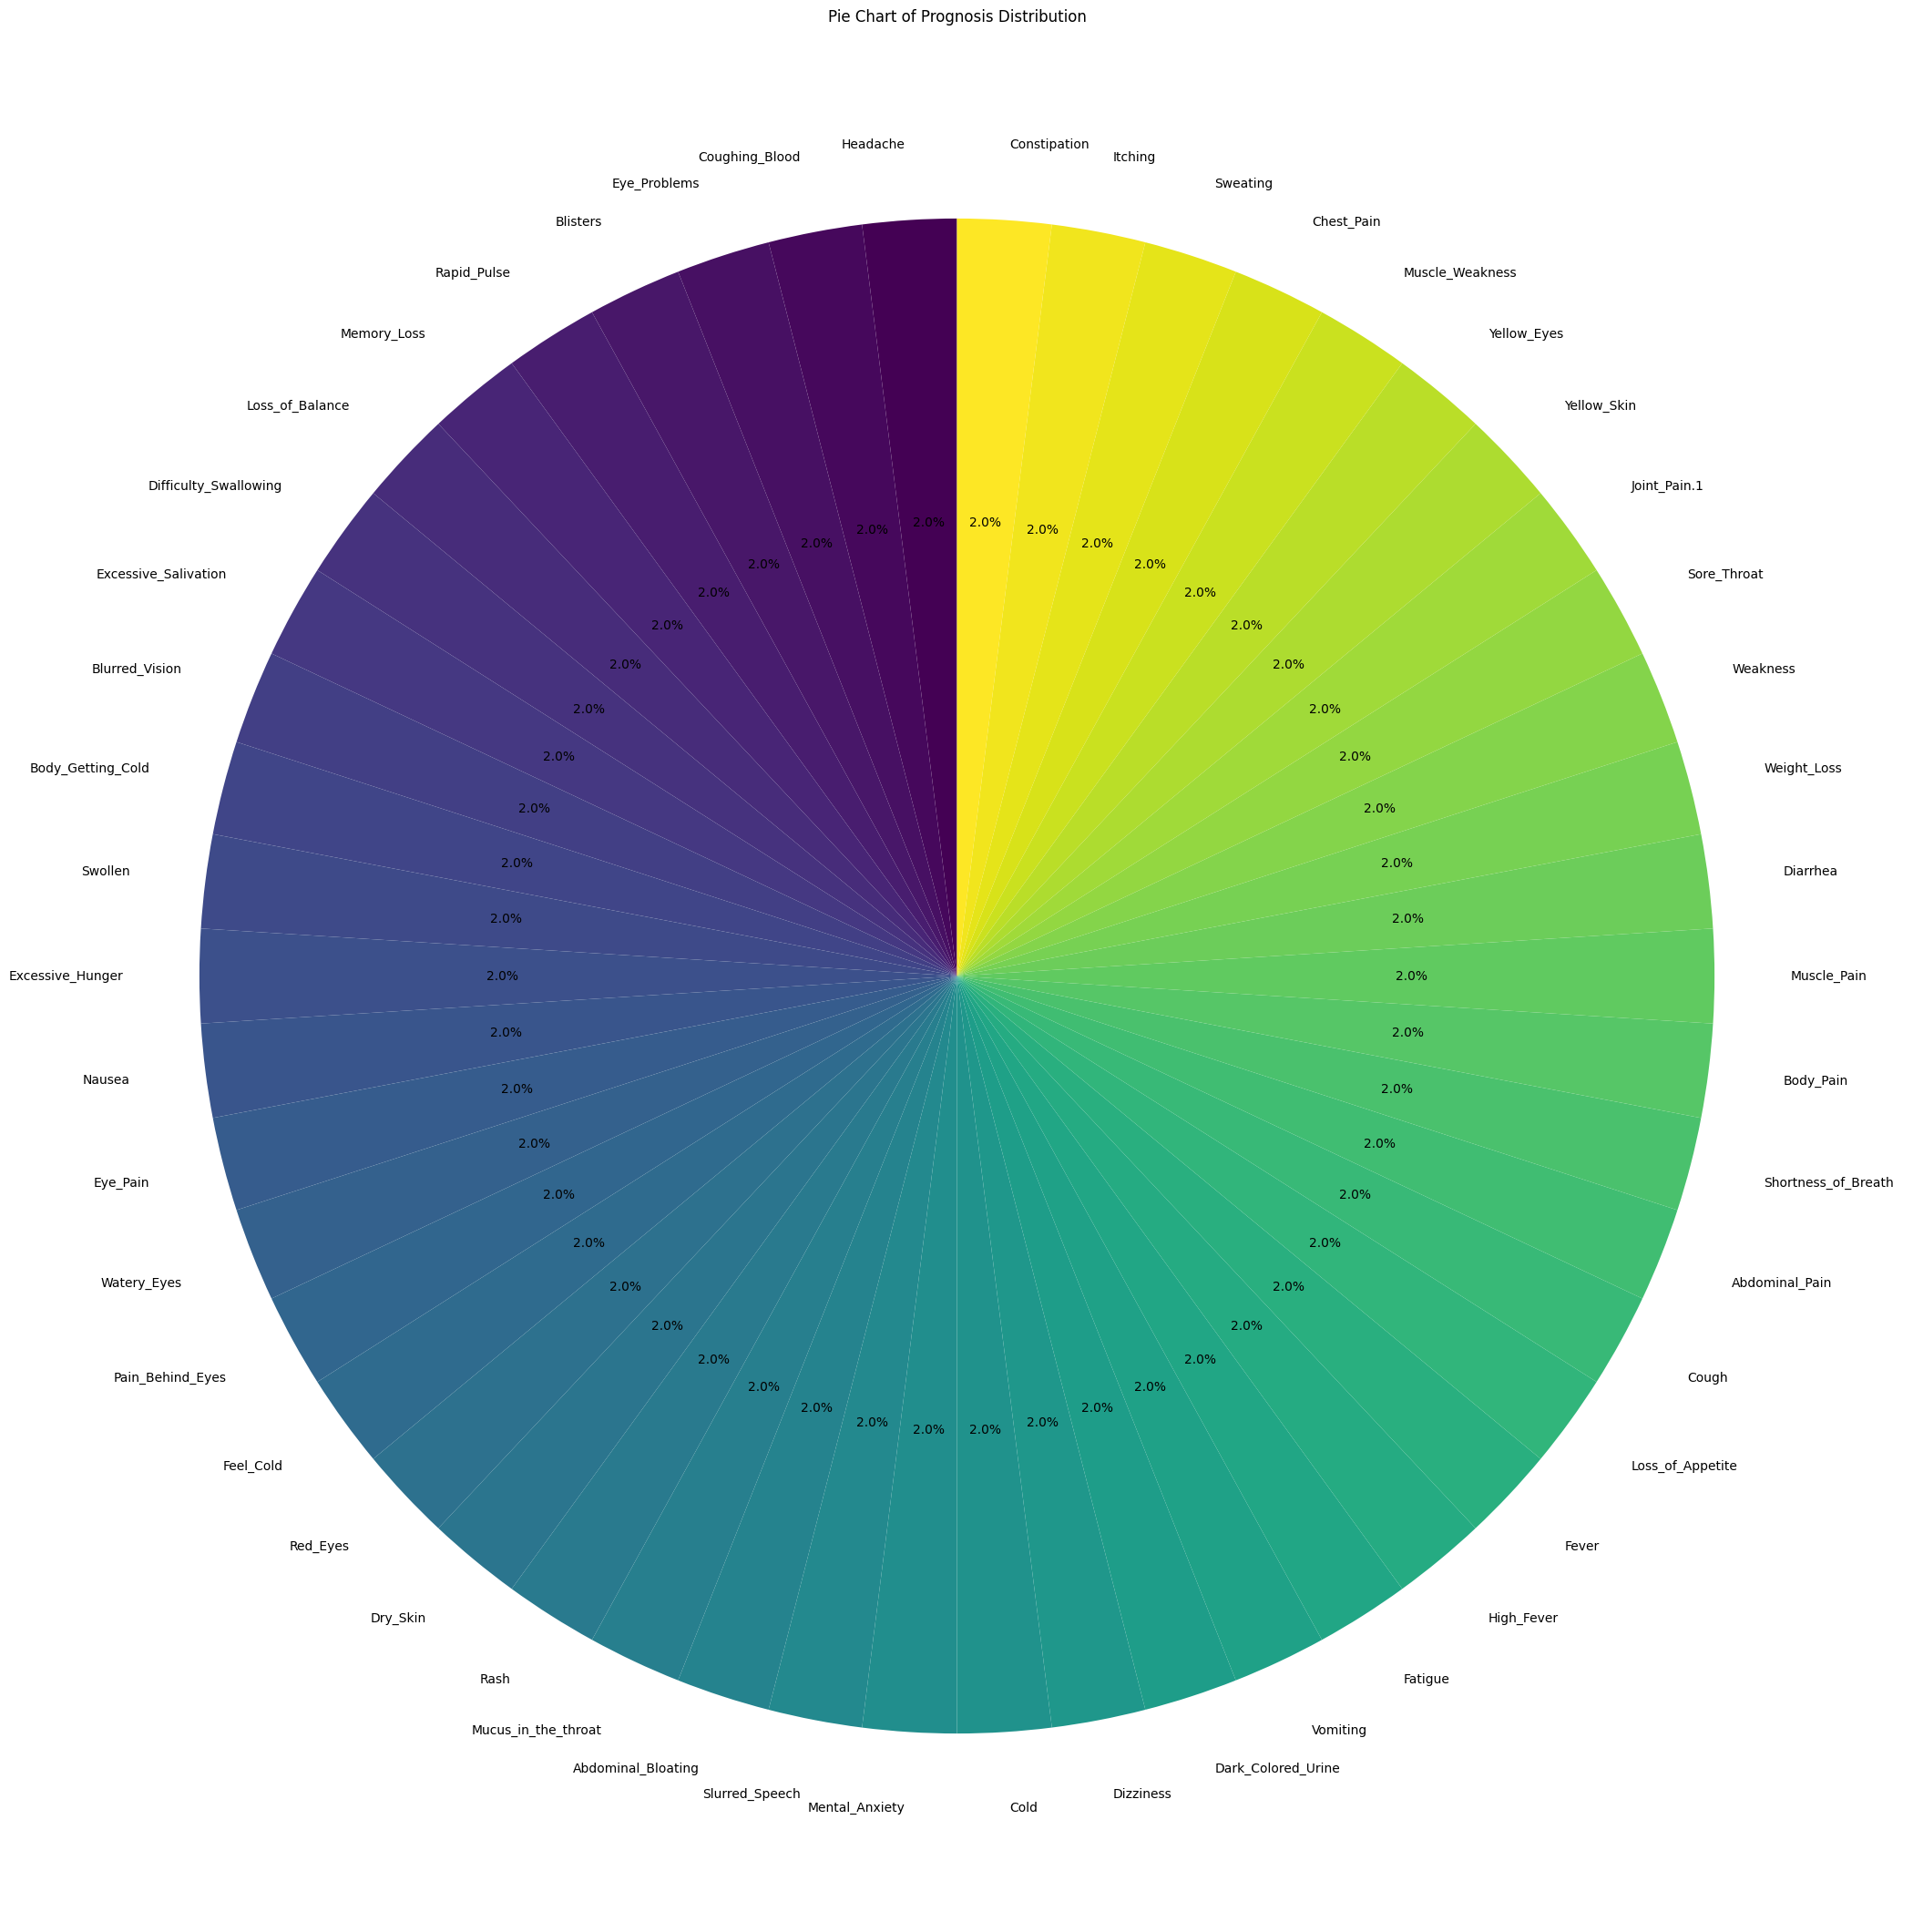

In [58]:
# Pie Chart of Prognosis Distribution

top_50= df.drop('Prognosis', axis=1).sum().sort_values(ascending=False).head(50).index

plt.figure(figsize=(27,27))
top_50.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Pie Chart of Prognosis Distribution')
plt.ylabel('') # Hide the y-label
plt.show()

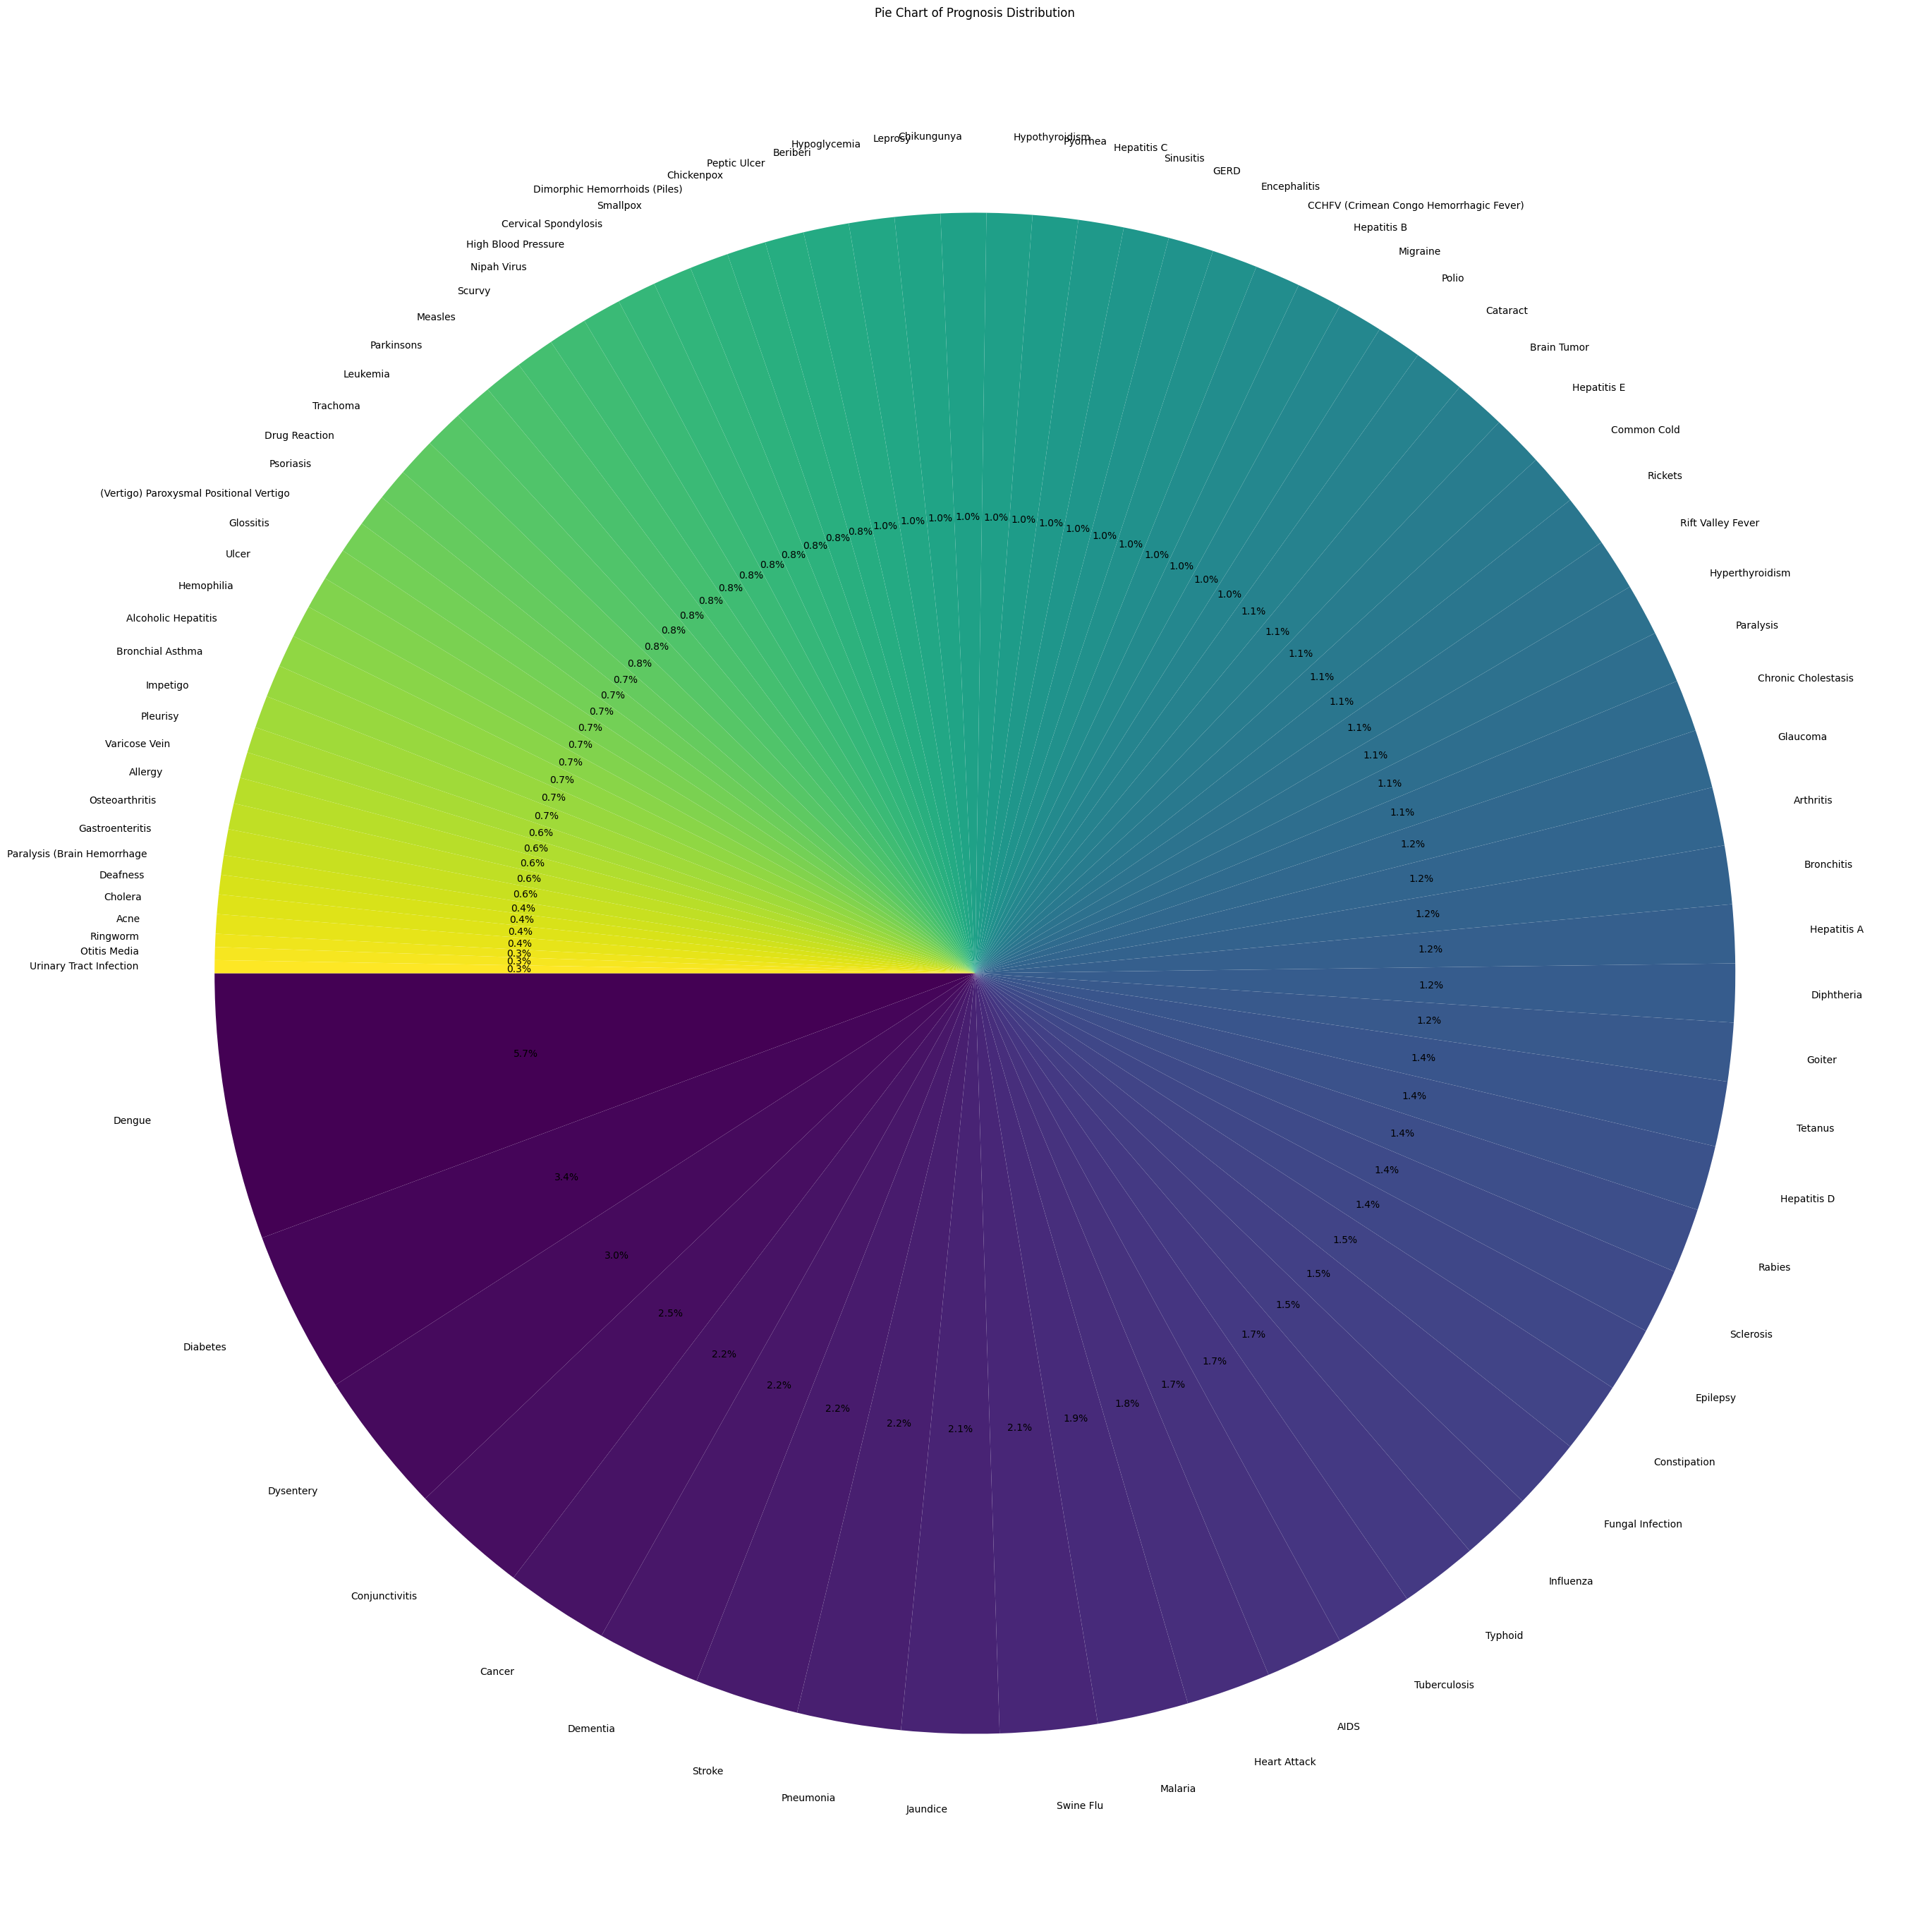

In [59]:
# Pie Chart of Prognosis Distribution

plt.figure(figsize=(35, 35))
df['Prognosis'].value_counts().plot.pie(autopct='%1.1f%%', startangle=180, cmap='viridis')
plt.title('Pie Chart of Prognosis Distribution')
plt.ylabel('') # Hide the y-label
plt.show()

In [60]:
# Separate features and target
X = df.drop('Prognosis', axis=1)
y = df['Prognosis']


# Encode the target variable 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("\nFeatures separated and target variable encoded.")


Features separated and target variable encoded.


In [61]:
# Data Splitting 
print("\n--- Data Splitting ---")


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


--- Data Splitting ---
X_train shape: (580, 172)
X_test shape: (145, 172)
y_train shape: (580,)
y_test shape: (145,)



--- Model Training and Hyperparameter Tuning ---

--- Training Decision Tree ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Decision Tree: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_split': 2}

Accuracy for Decision Tree: 0.6690
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.33      0.50         3
           2       0.50      1.00      0.67         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       0.50      1.00      0.67         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       0.50      1.00      0.67         1
          11   

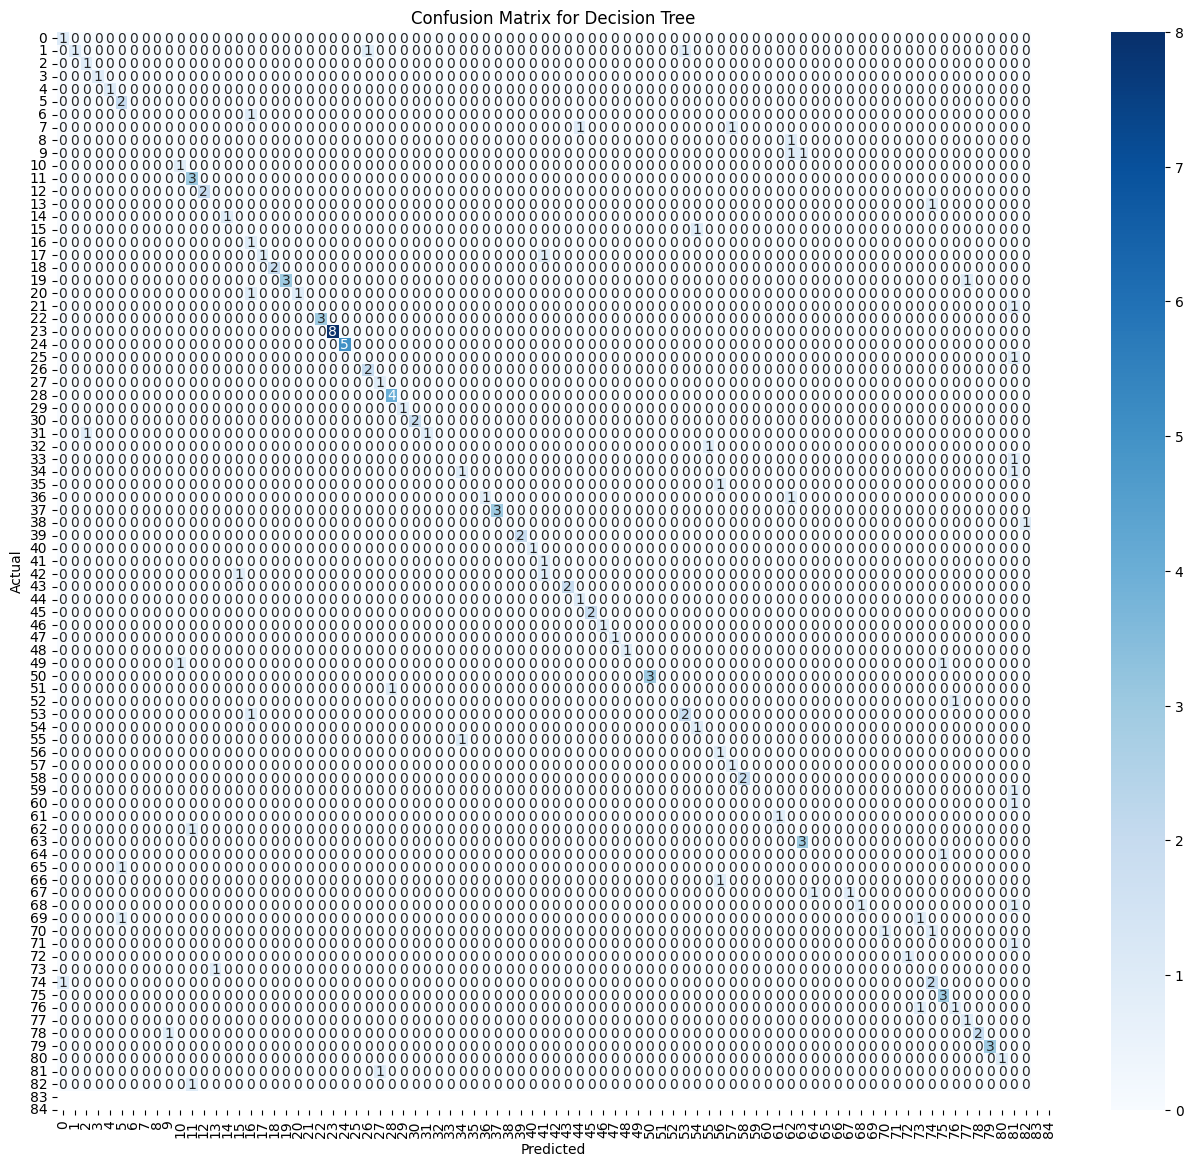


--- Training Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Random Forest: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}

Accuracy for Random Forest: 0.9655
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          11       0.75      1.00      0.86         3
          12

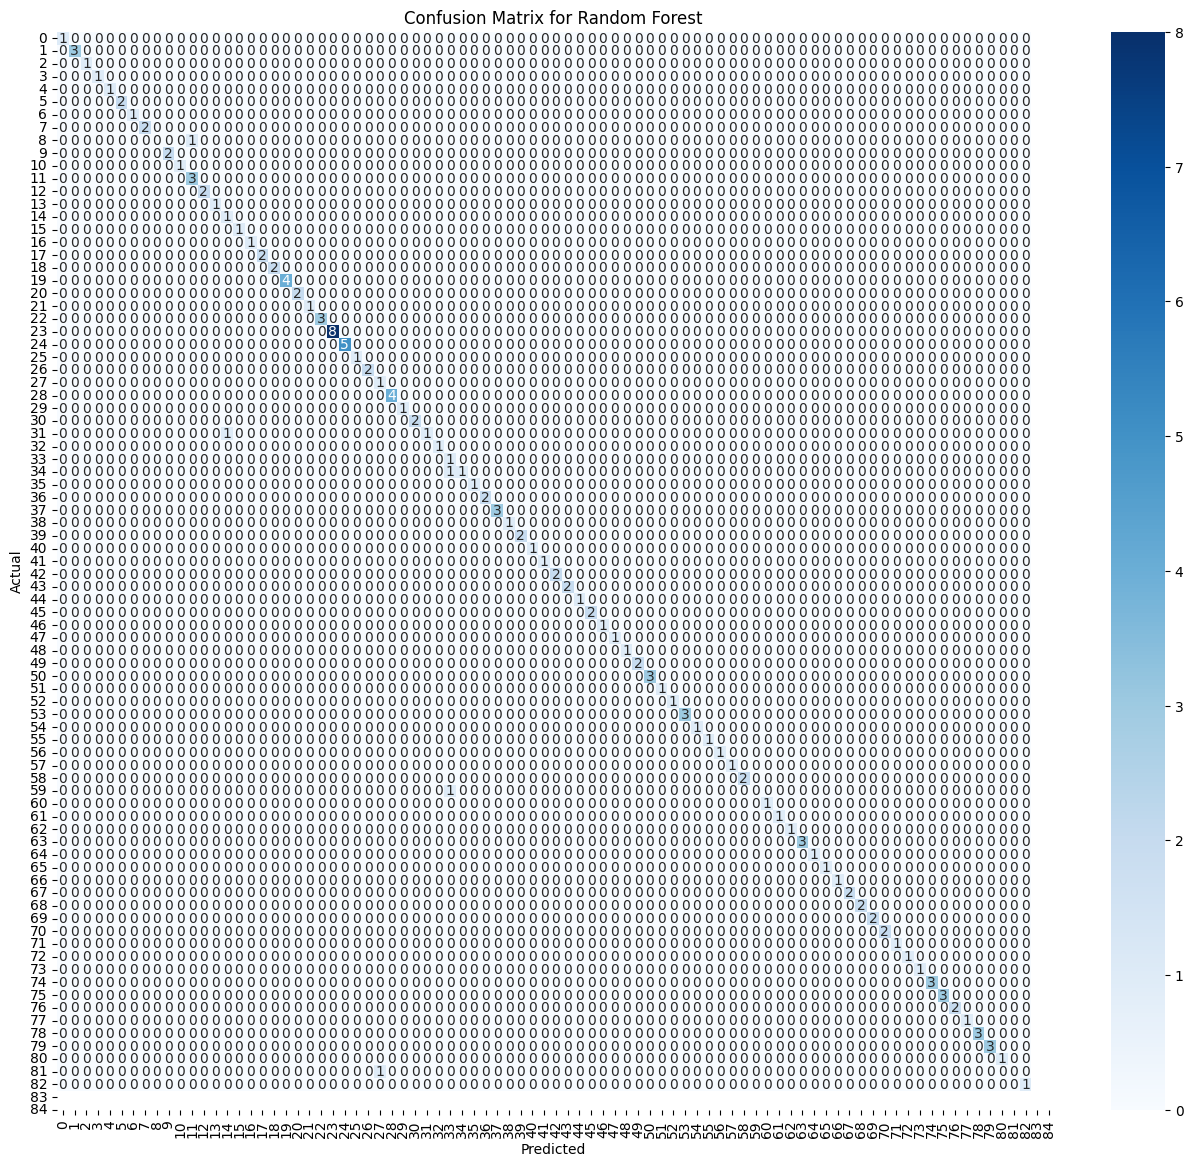


--- Training XGBoost ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for XGBoost: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100}

Accuracy for XGBoost: 0.6000
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       1.00      1.00      1.00         1
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       0.50      0.50      0.50         2
          10       0.00      0.00      0.00         1
          11       0.75      1.00      0.86         3
          12       0.00      0.00      0

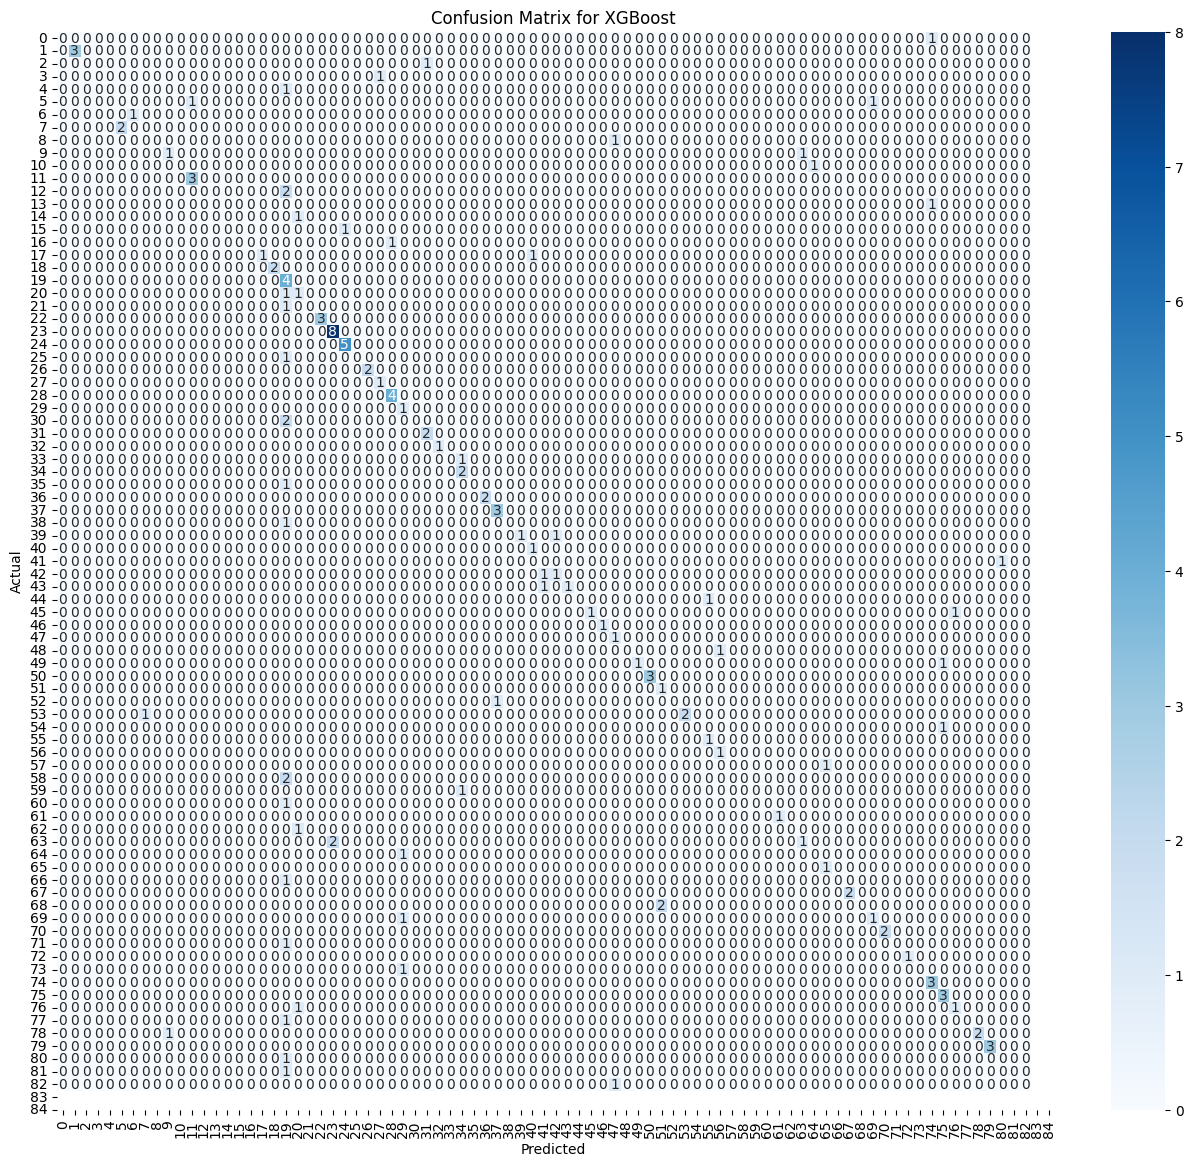

In [62]:
# Model Training and Hyperparameter Tuning ---
print("\n--- Model Training and Hyperparameter Tuning ---")


# Define pipelines for each model
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])


pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])


pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])


# Define hyperparameter grids
param_grid_dt = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10]
}


param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}


param_grid_xgb = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7]
}


# Create a list of pipelines and their parameter grids
pipelines = [pipeline_dt, pipeline_rf, pipeline_xgb]
param_grids = [param_grid_dt, param_grid_rf, param_grid_xgb]
model_names = ['Decision Tree', 'Random Forest', 'XGBoost']
results = {}
best_estimators = {}


# Loop through each model to perform GridSearchCV
for i, (pipeline, param_grid) in enumerate(zip(pipelines, param_grids)):
    print(f"\n--- Training {model_names[i]} ---")
    
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_estimators[model_names[i]] = best_model
    
    print(f"Best parameters for {model_names[i]}: {grid_search.best_params_}")
    
    # Evaluate the best model on the test set
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[model_names[i]] = accuracy
    
    print(f"\nAccuracy for {model_names[i]}: {accuracy:.4f}")
    print(f"Classification Report for {model_names[i]}:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
    plt.title(f'Confusion Matrix for {model_names[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()




--- Model Comparison ---
           Model  Accuracy
1  Random Forest  0.965517
0  Decision Tree  0.668966
2        XGBoost  0.600000


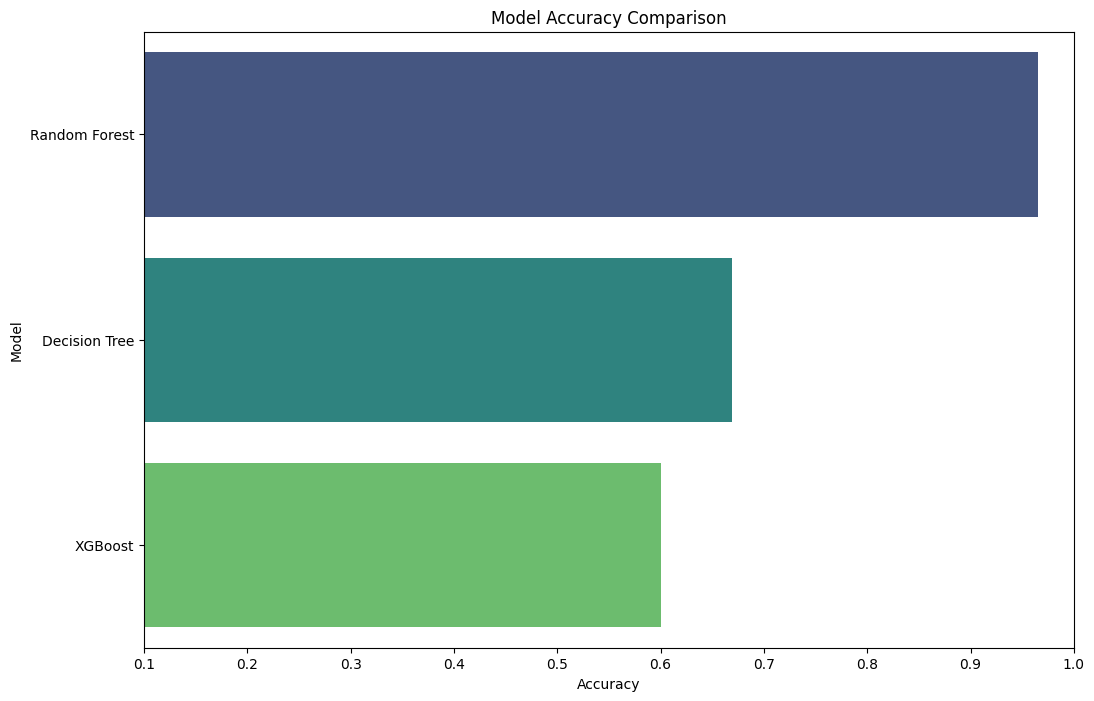

In [63]:
# --- 5. Model Comparison ---
print("\n--- Model Comparison ---")
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
print(results_df)


plt.figure(figsize=(12, 8))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.1, 1.0)
plt.show()

In [64]:
# Find the best model from the results
best_model_name = results_df.iloc[0]['Model']
best_model_to_save = best_estimators[best_model_name]


# Create a dictionary to save all necessary objects
model_data = {
    'model': best_model_to_save,
    'columns': X.columns,
    'label_encoder': le
}

print(f"\nSaving the best model and required objects: {best_model_name}")


# Save the dictionary to a file
filename = '../backend/Ai_model/model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model_data, file)


print(f"Model and objects saved to {filename}")


Saving the best model and required objects: Random Forest
Model and objects saved to ../backend/Ai_model/model.pkl


In [65]:
# Predict Disease from Symptoms ---
def predict_disease_from_file(symptoms):
    """
    Predicts the disease based on a list of symptoms by loading all required objects from a file.
    
    Args:
        symptoms (list): A list of symptom strings.
    """
    # Load the saved model and other objects
    with open('../backend/Ai_model/model.pkl', 'rb') as file:
        model_data = pickle.load(file)
    
    loaded_model = model_data['model']
    feature_columns = model_data['columns']
    label_encoder = model_data['label_encoder']
    
    # Create a zero-filled dataframe with the same columns
    test_df = pd.DataFrame(columns=feature_columns)
    test_df.loc[0] = 0
    
    # Set the symptom columns to 1
    for symptom in symptoms:
        if symptom in feature_columns:
            test_df[symptom] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not found in training data and will be ignored.")

    # Ensure the columns are in the same order as during training
    test_df = test_df[feature_columns]
    
    # Make prediction
    pred_label = loaded_model.predict(test_df)[0]
    
    # Decode the label back to the original class name
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    
    return pred_class


# Example usage:
my_symptoms = ['Itching', 'Burning_Sensation']
predicted_disease = predict_disease_from_file(my_symptoms)
print(f"\nBased on your symptoms, the predicted disease is: {predicted_disease}")


Based on your symptoms, the predicted disease is: Fungal Infection


In [66]:
# Summary 
summary = {
    "dataset_shape": df.shape,
    "num_symptoms": len(symptom_cols),
    "num_diseases": df['Prognosis'].nunique(),
    "most_common_disease": df['Prognosis'].value_counts().idxmax(),
    "least_common_disease": df['Prognosis'].value_counts().idxmin(),
    "most_common_symptom": symptom_counts.idxmax(),
    "least_common_symptom": symptom_counts.idxmin()
}
print("\nSummary Stats:\n", summary)


Summary Stats:
 {'dataset_shape': (725, 173), 'num_symptoms': 172, 'num_diseases': 85, 'most_common_disease': 'Dengue', 'least_common_disease': 'Ringworm', 'most_common_symptom': 'Headache', 'least_common_symptom': 'Sweating.1'}
